In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("bodyfat.csv")
data.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [3]:
print(data.shape)
print(data.info())
print(data.describe())

(252, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB
None
          Density     BodyFat         Age      Weight      Height        Neck  \
count  252.000000  252.000000  252.000000  252.000000  252.000000  252.000000   
mean     1.055574   

In [4]:
print(data.isnull().sum())

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64


In [5]:
X = data[['Age', 'Weight', 'Height']]
y = data['BodyFat']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)
print(y_pred)

[24.10592192 16.72515842 20.15676581 16.78258729 14.38286763 14.37262035
 18.80501845 21.78942538 17.8739536  15.70710299 29.0512763  24.35677939
 20.25659463 15.76893025 16.29540027  6.58302959 14.4968607  16.43610533
 17.76437054 11.57173828 21.27262844 22.71143107 19.48498667 18.46297458
 27.12649976 34.59791205 28.43481651 15.94633896 15.1406464  19.30132082
 17.57386484 18.59738901 18.79618197 23.92323366 23.56691265 11.00552396
 16.73988039 18.86725395 24.31657864 12.79639559 15.05506663 22.07565686
 23.07864676  9.9586836  14.00120883 20.58742524 20.75471604 14.58107787
 19.4441354  10.97867097 59.77356258]


In [9]:
print("Mean Absolute Error :", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

Mean Absolute Error : 4.864097192907689
Mean Squared Error : 37.90617810737113
R2 Score : 0.18513003378468829


In [10]:
comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred})
print(comparison.head(15))

    Actual  Predicted
0     19.2  24.105922
1     19.2  16.725158
2     28.0  20.156766
3     20.5  16.782587
4     16.7  14.382868
5     12.1  14.372620
6     23.6  18.805018
7     18.6  21.789425
8     11.7  17.873954
9     11.9  15.707103
10    26.1  29.051276
11    24.5  24.356779
12    14.8  20.256595
13    22.5  15.768930
14     6.3  16.295400


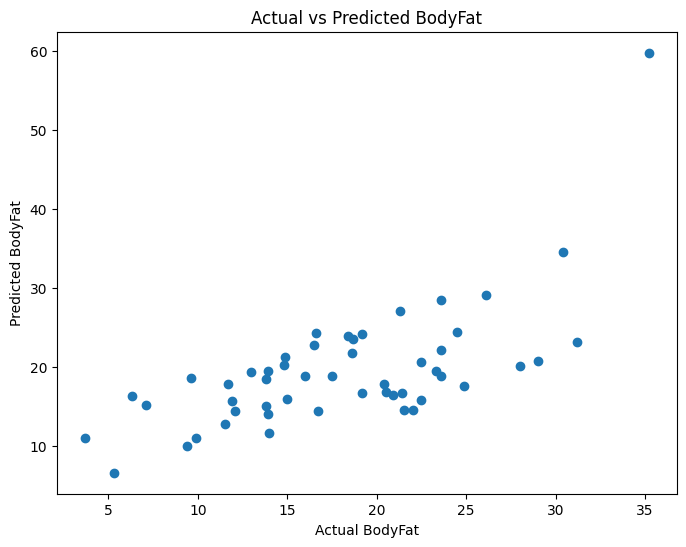

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual BodyFat")
plt.ylabel("Predicted BodyFat")
plt.title("Actual vs Predicted BodyFat")
plt.show()